# Watching a regulation change behavior: 10b5-1 plans

Form 4 filings flag whether a trade executed under a pre-arranged
Rule 10b5-1 plan. The checkbox itself arrived with the SEC's 2023
amendments, so the disclosure era starts there and the filings trace
adoption from day one of the rule.

This one pulls per-filing detail, a few hundred requests for a busy
issuer, so it is the slowest notebook in the set.

Needs `pandas` and `matplotlib`, and a free API key in
`THREESPREAD_API_KEY` ([signup](https://3spread.com/auth/signup)).

In [1]:
import pandas as pd

from py3spread import Client

TICKER = "AAPL"
client = Client(max_retries=8)  # long pull, ride through the per-minute rate limit

filings = list(client.insiders.iter(ticker=TICKER, form_type="4"))
print(f"{len(filings)} Form 4 filings on file for {TICKER}")

records = []
for f in filings:
    detail = client.insiders.get(f["filing_id"])
    records.append({
        "accepted": f["accepted_time"][:10],
        "planned": bool(detail.get("aff10b5_one")),
    })
df = pd.DataFrame(records)
df["quarter"] = pd.PeriodIndex(pd.to_datetime(df["accepted"]), freq="Q").astype(str)
era = df[df["quarter"] >= "2023Q1"]  # checkbox exists on the form from here
print(f"{era['planned'].mean():.0%} of filings since 2023 flag a 10b5-1 plan")

448 Form 4 filings on file for AAPL


23% of filings since 2023 flag a 10b5-1 plan


## Share of filings under a plan, by quarter

Pre-2023 filings cannot carry the flag (the field did not exist on the
form), so the series starts with the rule.

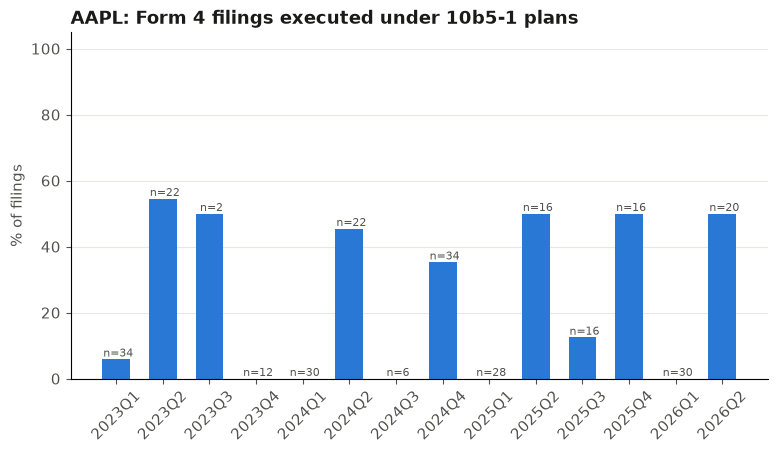

In [2]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e8e7e2",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "font.size": 11,
    "text.color": "#1a1a19",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
})
BLUE = "#2a78d6"
INK = "#52514e"


by_q = era.groupby("quarter").agg(share=("planned", "mean"), n=("planned", "size"))

fig, ax = plt.subplots()
ax.bar(by_q.index, by_q["share"] * 100, color=BLUE, width=0.6)
for x, (share, n) in enumerate(zip(by_q["share"], by_q["n"])):
    ax.text(x, share * 100, f" n={n}", ha="center", va="bottom", fontsize=8, color=INK)
ax.set_title(f"{TICKER}: Form 4 filings executed under 10b5-1 plans",
             loc="left", fontweight="bold")
ax.set_ylabel("% of filings")
ax.set_ylim(0, 105)
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="x", visible=False)
plt.show()

The zero quarters are real, not missing data: they are award and
vesting windows where every filing carries M/A/F/G transaction codes
(grants, option conversions, tax withholding, gifts) and no open-market
S sales, so nothing qualifies for the plan flag. The alternation is
Apple's equity-compensation calendar showing through.

The final bar is the in-progress quarter and will settle as it completes.

Quarterly counts are small for a single issuer (the n labels keep that
honest), so treat this as a company-level lens rather than a market
study. Run it across a watchlist and aggregate for the market version:
the flag is on every one of the 2.2M+ insider filing details.